In [3]:
!pip install datalab-client pyvo
!pip install /arc/home/calvin/chime-ffff-pz/
!pip install /arc/home/calvin/FRB/
!pip install openpyxl
!pip install aplpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.1/156.1 kB 13.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.8/994.8 kB 15.9 MB/s eta 0:00:00a 0:00:01
Processing /arc/home/calvin/chime-ffff-pz
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 7.5 MB/s eta 0:00:00a 0:00:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.3 MB/s eta 0:00:00ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.1/978.1 kB 105.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.9/378.9 kB 149.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 13.4 MB/s eta 0:00:00a 0:00:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.8/198.8 kB 218.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━

In [4]:
from glob import glob
from frb.surveys.decals import DECaL_Survey
from frb.surveys.panstarrs import Pan_STARRS_Survey
import numpy as np
import pandas as pd
from astropy.visualization import wcsaxes as wa
import aplpy
from astropy.io import fits
import os
import matplotlib.pyplot as plt
from chime_ffff_pz.path import plotting
import requests

# Step 0:
Change directory

In [5]:
PATH_TO_KKO_HOST_PAPER = '/arc/home/calvin/kko_host_paper' # Change as you see fit.
PATH_TO_CHIME_FFFF_PZ = '/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/'
final = pd.read_csv(os.path.join(PATH_TO_KKO_HOST_PAPER,'data_products/kko_full_cat.csv'))
final.set_index('chime_event_id',inplace=True)

In [6]:
path_runs = [s.split('/')[-1] for s in glob('/arc/home/calvin/kko_host_paper/data_products/b_err_1.3_PATH/*')]

# Plotting Routines, stolen from `chime-ffff-pz`

In [7]:
class FakePATH:
    def __init__(self,ra,dec,theta,a_err,b_err,candidates,type_str='eellipse_noshow'):
        self.localiz = {'type':type_str,
                        'eellipse':{'a':a_err * 3600,
                                    'b':b_err * 3600,
                                    'theta':theta},
                        'center_coord': coord.SkyCoord(ra=ra,dec=dec,unit = 'deg',frame='icrs')
                       }
        self.candidates = candidates
    

In [8]:
import astropy.coordinates as coord

In [9]:
import pandas

In [16]:
""" Routines for plotting PATH results """
import os

from io import BytesIO
from io import StringIO
import requests
from PIL import Image

import numpy as np
import pandas

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'axes.labelsize':20,
         'axes.titlesize':20,
         'xtick.labelsize':20,
         'ytick.labelsize':20}
pylab.rcParams.update(params)
from matplotlib import rc
#rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=False)

import aplpy

from reproject.mosaicking import find_optimal_celestial_wcs
from reproject import reproject_interp
from reproject.mosaicking import reproject_and_coadd

from astropy.coordinates import SkyCoord, angular_separation
from astropy import units 
from astropy.table import Table, vstack, unique
from astropy.io import fits
from astropy import utils as astropy_utils

from frb.surveys import survey_utils

from IPython import embed


# Create image with localization region and candidate hosts marked

def get_image_table_decal(tra, tdec, imsize=5.*units.arcmin, band='r'):
    """
    Get images from the catalog if available
        for a given fov and band.

    Args:
        tra, tdec = list of positions in degrees
        imsize (Quantity): FOV for the desired image
        band (str): Band for the image (e.g. 'r')
        timeout (int, optional): Time to wait in seconds before timing out
        verbose (bool, optional):

    Returns:
        HDU: Image header data unit
    """
    survey_str = 'DECaL'

    print(tra, tdec)
    img_table = None
    for ii in range(len(tra)):
        ra_t = tra[ii]
        dec_t = tdec[ii]
        # print("Getting image table for RA={0:.2f}, Dec={1:.2f}...".format(ra_t, dec_t))
        coord = SkyCoord(ra_t, dec_t, frame='icrs', unit=(units.deg, units.deg))
        survey = survey_utils.load_survey_by_name(
           survey_str, coord, imsize)

        table_cols, col_vals, bandstr = survey._parse_cat_band(band)

        # Search for images at the target dec
        img_table_t = survey.svc.search(coord, imsize, verbosity=2).to_table()

        # Select the indicated bandpass
        selection = [band in table_band for table_band in img_table_t['obs_bandpass'].astype(str)]
        # Select only image products
        for column, value in zip(table_cols, col_vals):
            selection = selection & ((img_table_t[column].astype(str) == value))
        img_table_t = img_table_t[selection]

        # Pick the image with the longest exposure time
        best_row = img_table_t[np.argmax(img_table_t['magzero'].data.data.astype('float'))]

        if ii == 0:
            img_table = img_table_t
        else:
            img_table = vstack([img_table, best_row])
    img_table_uniq = unique(img_table, keys=['obs_publisher_did'])
    return img_table_uniq


def get_image_table_panstarrs(tra, tdec, size=240, filters="grizy", format="fits", imagetypes="stack"):
    """Query ps1filenames.py service for multiple positions to get a list of images
    This adds a url column to the table to retrieve the cutout.

    tra, tdec = list of positions in degrees
    size = image size in pixels (0.25 arcsec/pixel)
    filters = string with filters to include
    format = data format (options are "fits", "jpg", or "png")
    imagetypes = list of any of the acceptable image types.  Default is stack;
        other common choices include warp (single-epoch images), stack.wt (weight image),
        stack.mask, stack.exp (exposure time), stack.num (number of exposures),
        warp.wt, and warp.mask.  This parameter can be a list of strings or a
        comma-separated string.

    Returns an astropy table with the results
    """
    ps1filename = "https://ps1images.stsci.edu/cgi-bin/ps1filenames.py"
    fitscut = "https://ps1images.stsci.edu/cgi-bin/fitscut.cgi"

    if format not in ("jpg","png","fits"):
        raise ValueError("format must be one of jpg, png, fits")
    # if imagetypes is a list, convert to a comma-separated string
    if not isinstance(imagetypes,str):
        imagetypes = ",".join(imagetypes)
    # put the positions in an in-memory file object
    cbuf = StringIO()
    cbuf.write('\n'.join(["{} {}".format(ra, dec) for (ra, dec) in zip(tra,tdec)]))
    cbuf.seek(0)
    # use requests.post to pass in positions as a file
    r = requests.post(ps1filename, data=dict(filters=filters, type=imagetypes),
        files=dict(file=cbuf))
    r.raise_for_status()
    tab = Table.read(r.text, format="ascii")

    urlbase = "{}?size={}&format={}".format(fitscut,size,format)
    tab["url"] = ["{}&ra={}&dec={}&red={}".format(urlbase,ra,dec,filename)
            for (filename,ra,dec) in zip(tab["filename"],tab["ra"],tab["dec"])]

    table_uniq = unique(tab, keys=['projcell', 'subcell'])
    return table_uniq

def geturl_radec_panstarrs(ra, dec, size=240, output_size=None, filters="grizy", format="jpg", color=False):

    """Get URL for images in the table

    ra, dec = position in degrees
    size = extracted image size in pixels (0.25 arcsec/pixel)
    output_size = output (display) image size in pixels (default = size).
                  output_size has no effect for fits format images.
    filters = string with filters to include
    format = data format (options are "jpg", "png" or "fits")
    color = if True, creates a color image (only for jpg or png format).
            Default is return a list of URLs for single-filter grayscale images.
    Returns a string with the URL
    """

    if color and format == "fits":
        raise ValueError("color images are available only for jpg or png formats")
    if format not in ("jpg","png","fits"):
        raise ValueError("format must be one of jpg, png, fits")
    #table = getimages(ra,dec,filters=filters)
    table = get_image_table_panstarrs(ra,dec,filters=filters)
    url = (f"https://ps1images.stsci.edu/cgi-bin/fitscut.cgi?"
           f"ra={ra}&dec={dec}&size={size}&format={format}")
    if output_size:
        url = url + "&output_size={}".format(output_size)
    # sort filters from red to blue
    flist = ["yzirg".find(x) for x in table['filter']]
    table = table[np.argsort(flist)]
    if color:
        if len(table) > 3:
            # pick 3 filters
            table = table[[0,len(table)//2,len(table)-1]]
        for i, param in enumerate(["red","green","blue"]):
            url = url + "&{}={}".format(param,table['filename'][i])
    else:
        urlbase = url + "&red="
        url = []
        for filename in table['filename']:
            url.append(urlbase+filename)
    return url

def getfits_radec_panstarrs(ra, dec, size=240, output_size=None, filters="g", fmt="jpg"):

    """Get grayscale image at a sky position

    ra, dec = position in degrees
    size = extracted image size in pixels (0.25 arcsec/pixel)
    output_size = output (display) image size in pixels (default = size).
                  output_size has no effect for fits format images.
    filter = string with filter to extract (one of grizy)
    format = data format (options are "jpg", "png")
    Returns the image
    """

    if fmt not in ("jpg","png","fits"):
        raise ValueError("format must be jpg, png, or fits")
    url = geturl_radec_panstarrs(ra,dec,size=size,filters=filters,output_size=output_size,format=fmt)
    if fmt == 'fits':
        im = fits.open(url[0])
    else:
        r = requests.get(url[0])
        im = Image.open(BytesIO(r.content))
    return im


def grab_image_wcs(center_coord, target_ras, target_decs,
                   size_arcmins:float=2., filt:str='r', 
                   survey_str:str='Pan-STARRS'):
        # Get table of images containing the above RA/Decs
    im_fits = []
    if survey_str == 'Pan-STARRS':
        size_pixels = int(size_arcmins * 60. / 0.25)
        table = get_image_table_panstarrs(target_ras, target_decs, 
                                          filters=filt, 
                                          size=size_pixels) #filters="i"
        # Get all FITS images
        for ii in range(len(table)):
            url = table[ii]['url']
            print("Loading fits: {}".format(url))
            im = fits.open(url)
            im_fits.append(im)
    elif survey_str == 'DECaL':
        print(target_ras, target_decs)
        table = get_image_table_decal(target_ras, target_decs, 
                                      imsize=size_arcmins*units.arcmin, 
                                      band=filt)
        # Get all FITS images
        for ii in range(len(table)):
            url = table[ii]['access_url']
            print("Loading fits: {}".format(url))
            im = fits.open(astropy_utils.data.download_file(
                url, cache=False,
                show_progress=False, timeout=1200,
            ))
            im_fits.append(im)
    else:
        raise IOError(f"Not ready for this survey: {survey_str}")

    # Calculate an optimal WCS to share between all the fits
    res = 0.25*units.arcsec
    if len(im_fits) > 1:
        res = 1*units.arcsec
    wcs_out, shape_out = find_optimal_celestial_wcs(
        im_fits,
        resolution = res,
        reference = center_coord,
    )

    # Reproject and combine fits onto new WCS
    array, footprint = reproject_and_coadd(
        im_fits, wcs_out, shape_out=shape_out,
        reproject_function=reproject_interp,
    )

    return array, wcs_out, im_fits, footprint


# TODO: There's a lot of mature with this function. Look at different surveys,
# plot more useful metadata, etc.
def plot_localization_diagnostic(
    path_obj, # Path object with information about the localization
    name:str,
    size_arcmins:float=None, # Size of image to query in arcmins
    filt:str="r", # Filter to query (one of grizy)
    P_Ox_thresh:float=0.1, # A posterior threshold for declaring candidates "interesting" enough for including on the diagnostic plot
    outfile:str=None,
    survey_str:str='Pan-STARRS',
    stars:Table=None):
    """ Plot a diagnostic image for a given FRB localization
    and PATH results

    Args:
        path_obj (_type_): _description_
        size_arcmins (float, optional): _description_. Defaults to None.
        survey_str (str, optional): _description_. Defaults to 'Pan-STARRS'.

    Raises:
        ValueError: _description_
        IOError: _description_
        IOError: _description_

    Returns:
        _type_: _description_
    """

    if size_arcmins is None:
        if path_obj.localiz['type'] == 'eellipse':
            frb_coord = path_obj.localiz['center_coord']
            size_arcmins = 3.*5.*path_obj.localiz['eellipse']['a'] / 60.
            size_arcmins = max(1., size_arcmins)  # At least 1 arcmin
            size_arcmins = min(20., size_arcmins)  # No bigger than 20
        else:
            raise ValueError("size_arcmins must be specified if localization is not an eellipse")

    size_pixels = int(size_arcmins * 60. / 0.25)

    cands = path_obj.candidates
    interesting_cands = cands[cands['P_Ox'] > P_Ox_thresh]

    # Make a list of RA/Decs to make sure the plot includes
    # Input RA/Decs of interesting candidates
    target_ras = interesting_cands['ra'].tolist()
    target_decs = interesting_cands['dec'].tolist()

    # Include FRB localization
    if path_obj.localiz['type'] == 'eellipse':
        frb_coord = path_obj.localiz['center_coord']
        target_ras.append(frb_coord.ra.deg)
        target_decs.append(frb_coord.dec.deg)

        factor = 2. # a fudge

        offset1 = frb_coord.directional_offset_by(
            path_obj.localiz['eellipse']['theta'] * units.deg,
            factor*3*path_obj.localiz['eellipse']['a'] * units.arcsec)
        offset2 = frb_coord.directional_offset_by(
            path_obj.localiz['eellipse']['theta'] * units.deg,
            -factor*3*path_obj.localiz['eellipse']['a'] * units.arcsec)

        # Input locations beyond the FRB localization limits
        target_ras.append(offset1.ra.deg)
        target_decs.append(offset1.dec.deg)
        target_ras.append(offset2.ra.deg)
        target_decs.append(offset2.dec.deg)
    else:
        raise IOError("Only eellipse localizations supported at the moment")

    #embed(header='255 of plotting')
    #target_ras = [94.84722946, 94.84039208, 94.86030721726925, 94.9368431217593, 94.78377131277921, 94.86030721726925, 94.86030721726925]
    #target_decs = [43.22869561, 43.23724529, 43.245839176731735, 43.245839176731735, 43.245839176731735, 43.316949475975406, 43.174728877488064]

    # Grab it
    array, wcs_out, im_fits, footprint = grab_image_wcs(
        frb_coord, target_ras, target_decs,
        size_arcmins=size_arcmins, filt=filt, survey_str=survey_str)


    # If using the Dark Energy Legacy Survey, do a bit of cleaning to deal with
    # saturation from bright sources/stars
    if survey_str == 'DECaL':
        array[array>0.5] = np.nan
        array[array<-0.5] = np.nan
    # Create at new HDU for the combined fits
    hdu = fits.PrimaryHDU(array, header=wcs_out.to_header())

    # Old way of doing things
    # gim = getfits_radec(ra, dec, size=size_pixels, filters=filt, fmt='jpg')

    sup_fig = plt.figure(figsize=(10, 10))

    try:
        fig = aplpy.FITSFigure(hdu, figure=sup_fig)
    except:
        embed(header='Error in aplpy.FITSFigure')

    fig.show_colorscale(cmap='viridis', stretch='sqrt')
    fig.tick_labels.set_font(size=20)
    fig.axis_labels.set_font(size=20)
    fig.axis_labels.set_xtext('Right Ascension (J2000)')
    fig.axis_labels.set_ytext('Declination (J2000)')
    fig.set_title("{0} {1}-Filter Image for {2}".format(
        survey_str, filt, name), fontsize=20)
    fig.add_grid()
    fig.grid.set_color('white')
    fig.grid.set_alpha(0.5)
    fig.grid.set_linestyle('solid')
    fig.grid.set_linewidth(1)
    ra, dec = frb_coord.ra.deg, frb_coord.dec.deg
    fig.show_markers(ra, dec, facecolor='white', marker='+', s=300)


    # Localization
    # Note: width and height parameters should be 2 times semi-major/minor axes
    if path_obj.localiz['type'] == 'eellipse':
        fig.show_ellipses(ra, dec, 2.*path_obj.localiz['eellipse']['a'] / 3600., 
                          2.*path_obj.localiz['eellipse']['b'] / 3600., 
                          angle=90+path_obj.localiz['eellipse']['theta'],
                          edgecolor='white', lw=1.5)
        fig.show_ellipses(ra, dec, 3*2.*path_obj.localiz['eellipse']['a'] / 3600., 
                          3*2.*path_obj.localiz['eellipse']['b'] / 3600., 
                          angle=90+path_obj.localiz['eellipse']['theta'],
                          edgecolor='white', lw=1.5, ls='dashed')
        
    # Stars?
    if stars is not None:
        fig.show_markers(stars['ra'], stars['dec'], 
                         color='red', marker='x', s=10)

    # PATH P(O|x)
    fig.add_label(1.05, .9, "Path PO_x", color='black', size=20, relative=True, horizontalalignment='left', weight='bold')
    jj = 1
    offsets = []
    for ii, cand in interesting_cands.iterrows():
        ra_cand = cand['ra']
        dec_cand = cand['dec']
        fig.show_markers(ra_cand, dec_cand, edgecolor='red', facecolor='none', marker='s', s=100, lw=1.5)
        label_x_loc = ra_cand
        label_y_loc = dec_cand + 5./3600.
        fig.add_label(label_x_loc, label_y_loc, str(jj), color='red', size=15)
        fig.add_label(1.05, .9-0.05*jj, "{0}:  {1:.3f}".format(jj,cand['P_Ox']), color='black', size=20, relative=True, horizontalalignment='left')
        jj = jj + 1
        coord_cand = SkyCoord(ra_cand, dec_cand, unit=(units.deg, units.deg), frame='icrs')
        offset = angular_separation(frb_coord.ra.rad, frb_coord.dec.rad, coord_cand.ra.rad, coord_cand.dec.rad) * 180. / np.pi # deg
        offsets.append(offset)

    other_sources = cands[(cands['P_Ox'] < P_Ox_thresh) & (cands['P_Ox'] > 10**(-3))]
    for ii, cand in other_sources.iterrows():
        ra_cand = cand['ra']
        dec_cand = cand['dec']
        fig.show_markers(ra_cand, dec_cand, edgecolor='blue', facecolor='none', marker='o', s=10, lw=1.5)

    # Adjustable final zoom into the localization region, but encompassing
    # any interesting sources
    print(np.array(offsets)*60*2, size_arcmins)
    zoom_width = np.nanmax([np.nanmax(offsets, initial=0)*60*2, size_arcmins])
    fig.recenter(ra, dec, width=zoom_width/60., height=zoom_width/60.)
    print(ra,dec)

    if outfile is not None:
        plt.savefig(outfile, dpi=100, format="png", bbox_inches="tight")
    plt.close()

    return hdu


########################################################################################################################################################
########################################################################################################################################################
########################################################################################################################################################

# Below are the functions used for plotting color images from Pan-STARRS or DECaLs

ps1filename = "https://ps1images.stsci.edu/cgi-bin/ps1filenames.py"
ps1fitscut = "https://ps1images.stsci.edu/cgi-bin/fitscut.cgi"

def get_color_image_table_panstarrs(ra, dec, size_arcmin=1., filters="grizy", format="fits"):
    """Query ps1filenames.py service to get a list of images
    
    ra, dec = position in degrees
    size_arcmin = extracted image size in arcmins (0.25 arcsec/pixel)
    filters = string with filters to include
    format = data format (options are "jpg", "png" or "fits")
    color = if True, creates a color image (only for jpg or png format).
            Default is return a list of URLs for single-filter grayscale images.

    Returns a table with the results
    """
    conversion_arcsec_to_pix = 0.25
    size = int(size_arcmin * 60. / conversion_arcsec_to_pix)
    
    # Get the table for the given RA/Dec and filters
    service = "https://ps1images.stsci.edu/cgi-bin/ps1filenames.py"
    url = f"{service}?ra={ra}&dec={dec}&filters={filters}"
    table = Table.read(url, format='ascii')
    
    # Add the query URLs into the table
    url = (f"https://ps1images.stsci.edu/cgi-bin/fitscut.cgi?"
           f"ra={ra}&dec={dec}&size={size}&format={format}")
    # Sort filters from red to blue
    flist = ["yzirg".find(x) for x in table['filter']]
    table = table[np.argsort(flist)]
    # If more than 3 filters listed, pick the 3 most spread out
    if len(table) > 3:
        table = table[[0, len(table)//2, len(table)-1]]
    # Add colors to the urls and populate the table
    table["url"] = None
    for ii, param in enumerate(["red","green","blue"]):
        table["url"][ii] = "{}&{}={}".format(url, param, table['filename'][ii])
    
    return table


def get_images_panstarrs(ra,dec,filters="grizy"):
    
    """Query ps1filenames.py service to get a list of images
    
    ra, dec = position in degrees
    size = image size in pixels (0.25 arcsec/pixel)
    filters = string with filters to include
    Returns a table with the results
    """
    
    service = "https://ps1images.stsci.edu/cgi-bin/ps1filenames.py"
    url = f"{service}?ra={ra}&dec={dec}&filters={filters}"
    table = Table.read(url, format='ascii')
    return table


def get_url_panstarrs(ra, dec, size=240, output_size=None, filters="grizy", format="jpg", color=False, scale=99.9):
    
    """Get URL for images in the table
    
    ra, dec = position in degrees
    size = extracted image size in pixels (0.25 arcsec/pixel)
    output_size = output (display) image size in pixels (default = size).
                  output_size has no effect for fits format images.
    filters = string with filters to include
    format = data format (options are "jpg", "png" or "fits")
    color = if True, creates a color image (only for jpg or png format).
            Default is return a list of URLs for single-filter grayscale images.
    Returns a string with the URL
    """
    
    if color and format == "fits":
        raise ValueError("color images are available only for jpg or png formats")
    if format not in ("jpg","png","fits"):
        raise ValueError("format must be one of jpg, png, fits")
    table = get_images_panstarrs(ra,dec,filters=filters)
    url = (f"https://ps1images.stsci.edu/cgi-bin/fitscut.cgi?"
           f"ra={ra}&dec={dec}&size={size}&format={format}")
    if output_size:
        url = url + "&output_size={}".format(output_size)
    # sort filters from red to blue
    flist = ["yzirg".find(x) for x in table['filter']]
    table = table[np.argsort(flist)]
    if color:
        if len(table) > 3:
            # pick 3 filters
            table = table[[0,len(table)//2,len(table)-1]]
        for i, param in enumerate(["red","green","blue"]):
            url = url + "&{}={}".format(param,table['filename'][i])
    else:
        urlbase = url + "&red="
        url = []
        for filename in table['filename']:
            url.append(urlbase+filename)
    
    #Adjust contrast
    url = url + "&autoscale={}".format(scale)
    print(url)
    
    return url


def get_color_png_panstarrs(ra, dec, size=240, output_size=None, filters="grizy", scale=99.9):
    
    """Get color image at a sky position
    
    ra, dec = position in degrees
    size = extracted image size in pixels (0.25 arcsec/pixel)
    output_size = output (display) image size in pixels (default = size).
                  output_size has no effect for fits format images.
    filters = string with filters to include
    format = data format (options are "jpg", "png")
    Returns the image
    """
    url = get_url_panstarrs(ra,dec,size=size,filters=filters,output_size=output_size,format="png",color=True, scale=scale)
    r = requests.get(url)
    im = Image.open(BytesIO(r.content))
    return im


desi_jpeg_url = 'https://www.legacysurvey.org/viewer/jpeg-cutout'
desi_fits_url = 'https://www.legacysurvey.org/viewer/fits-cutout'
def get_color_png_desi(ra, dec, size_pix=512, conversion_arcsec_to_pix = 0.262, filt="grz"):
    
    """Get color image at a sky position
    
    ra, dec = position in degrees
    size = extracted image size in pixels (0.25 arcsec/pixel)
    output_size = output (display) image size in pixels (default = size).
                  output_size has no effect for fits format images.
    filters = string with filters to include
    format = data format (options are "jpg", "png")
    Returns the image
    """
    url = '{}?ra={}&dec={}&width={}&height={}&layer=ls-dr10&pixscale={}&bands={}'.format(
        desi_jpeg_url, ra, dec, 
        size_pix, size_pix, 
        conversion_arcsec_to_pix, filt
    )
    print('DESI URL:',url)
    r = requests.get(url, stream=True, verify=True)
    im = Image.open(BytesIO(r.content))
    return im

def get_color_fits_desi(ra, dec, size_pix=512, conversion_arcsec_to_pix = 0.262, filt="grz"):
    
    """Get color image at a sky position
    
    ra, dec = position in degrees
    size = extracted image size in pixels (0.25 arcsec/pixel)
    output_size = output (display) image size in pixels (default = size).
                  output_size has no effect for fits format images.
    filters = string with filters to include
    format = data format (options are "jpg", "png")
    Returns the image
    """
    url = '{}?ra={}&dec={}&width={}&height={}&layer=ls-dr10&pixscale={}&bands={}'.format(
        desi_fits_url, ra, dec, 
        size_pix, size_pix, 
        conversion_arcsec_to_pix, filt
    )
    print('DESI URL:',url)
    im = fits.open(url)
    return im

def plot_color_image(
    sup_fig,
    path_obj, TNS_name:str,
    path_to_rgb=None,
    size_arcmin=None,
    zoom_width=None,
    zoom_height=None,
    filt="gri", 
    survey_str='Pan-STARRS',
    outfile : str = None,
    scale=99.88,   # How best to stretch the image (FOV dependent for PS)
    results_table:pandas.DataFrame=None,
    stars=None,
    delete = True,
    flip = True,
    **show_colorscale_kwargs):

    # RA, Dec
    if 'eellipse' in path_obj.localiz['type']:
        frb_coord = path_obj.localiz['center_coord']
        ra, dec = frb_coord.ra.deg, frb_coord.dec.deg
    else:
        raise IOError("Only eellipse localizations supported")

    # Size of image
    if size_arcmin is None:
        if path_obj.localiz['type'] == 'eellipse':
            frb_coord = path_obj.localiz['center_coord']
            size_arcmin = 3.*5.*path_obj.localiz['eellipse']['a'] / 60.
            size_arcmin = max(1., size_arcmin)  # At least 1 arcmin
            size_arcmin = min(20., size_arcmin)  # No bigger than 20
        else:
            raise ValueError("size_arcmins must be specified if localization is not an eellipse")

    output_fn = os.path.split(outfile)[0] + f'/{TNS_name}_rgb_2d.fits'
    if not os.path.exists(output_fn):

        if survey_str == 'Pan-STARRS':
            conversion_arcsec_to_pix = 0.25
            size_pix = int(size_arcmin * 60. / conversion_arcsec_to_pix)

            print('Get nice {} PNG of {} pixels'.format(survey_str, size_pix))
            cim_png = get_color_png_panstarrs(ra, dec, size=size_pix, filters=filt, scale=scale)
            print('Get available fits from {} at given location'.format(survey_str))
            img_table = get_color_image_table_panstarrs(
                ra, dec, size_arcmin=size_arcmin, filters=filt, format="fits")

            print('Load all the RGB fits images')
            im_fits_orig = []
            for ii in range(len(img_table)):
                url = img_table[ii]['url']
                print("Loading fits: {}".format(url))
                im = fits.open(url)
                im_fits_orig.append(im)
            hdu_orig_fits = im_fits_orig[0][0].header
        elif survey_str == 'DECaL':
            conversion_arcsec_to_pix = 0.262
            size_pix = int(size_arcmin * 60. / conversion_arcsec_to_pix)
            print('Get nice {} PNG of {} pixels with conversion scale of {} arcseconds per pixel'.format(survey_str, size_pix, conversion_arcsec_to_pix))
            cim_png = get_color_png_desi(ra, dec, size_pix=size_pix, conversion_arcsec_to_pix=conversion_arcsec_to_pix, filt=filt)
            print('Get available fits from {} at given location'.format(survey_str))
            im_fits = get_color_fits_desi(ra, dec, size_pix=size_pix, conversion_arcsec_to_pix=conversion_arcsec_to_pix, filt=filt)
            hdu_orig_fits = im_fits[0].header
        else:
            raise IOError('Survey string not recognized!')

        print('Convert color png into fits')
        xsize, ysize = cim_png.size
        r, g, b = cim_png.split()
        r_data = np.array(r.getdata()) # data is now an array of length ysize*xsize
        g_data = np.array(g.getdata())
        b_data = np.array(b.getdata())
        if flip:
            assert delete == True, "Must delete if you are flipping!"
            r_data = r_data.reshape(xsize, ysize)[::-1,::-1] # data is now a matrix (xsize, ysize)
            g_data = g_data.reshape(xsize, ysize)[::-1,::-1]
            b_data = b_data.reshape(xsize, ysize)[::-1,::-1]
        else:
            r_data = r_data.reshape(xsize, ysize)[:,::-1] # data is now a matrix (xsize, ysize)
            g_data = g_data.reshape(xsize, ysize)[:,::-1]
            b_data = b_data.reshape(xsize, ysize)[:,::-1]
            
        data = [r_data, g_data, b_data]

        im_fits = []
        for ii in range(len(data)):
            hdu = fits.PrimaryHDU(data[ii], header=hdu_orig_fits)
            im_fits.append(hdu)

        print('Calculate an optimal WCS to share between all the fits')
        coord = SkyCoord(ra, dec, unit=(units.deg, units.deg), frame='icrs')
        res = 0.25*units.arcsec
        wcs_out, shape_out = find_optimal_celestial_wcs(
            im_fits,
            resolution = res,
            reference = coord,
        )
        header_out = wcs_out.to_header()

        print('Generate empty datacube, reprojecting each color to the new WCS')
        image_cube = np.zeros((len(im_fits),) + shape_out, dtype=np.float32)
        for ii, im in enumerate(im_fits):
            array, footprint = reproject_interp(im, wcs_out, shape_out=shape_out)
            image_cube[ii, :, :] = array[:,::-1]

        print('Write out collapsed version of cube for aplpy plotting purposes')
        fits.writeto(
            output_fn,
            np.mean(image_cube, axis=0), 
            header_out, 
            overwrite=True,
        )

        print('Save the reprojected fits into a PNG, also for aplpy plotting purposes')
        img = Image.merge("RGB", (
            Image.fromarray(image_cube[0].astype(np.uint8)), 
            Image.fromarray(image_cube[1].astype(np.uint8)), 
            Image.fromarray(image_cube[2].astype(np.uint8)),
        ))

        img.save(output_fn.replace('_2d.fits', '.png'))
    print('Make plot!')
    print(output_fn)
    fig = aplpy.FITSFigure(output_fn, figure=sup_fig)
    if path_to_rgb is None:
        fig.show_colorscale(**show_colorscale_kwargs)
    else:
        fig.show_rgb(filename=path_to_rgb,vertical_flip=True)
    fig.tick_labels.set_font(size=20)
    fig.axis_labels.set_font(size=20)
    fig.axis_labels.set_xtext('Right Ascension (J2000)')
    fig.axis_labels.set_ytext('Declination (J2000)')
    #fig.set_title("{0} {1}-Image for FRB: {2}".format(
    #    survey_str, filt, TNS_name), fontsize=20)
    fig.add_grid()
    fig.grid.set_color('white')
    fig.grid.set_alpha(0.5)
    fig.grid.set_linestyle('solid')
    fig.grid.set_linewidth(1)
    #fig.show_markers(ra, dec, facecolor='black', marker='+', s=300)
    fig.add_scalebar(length = 3/3600, corner = 'bottom left',height = 0.5,label = '3"')
    # Note: width and height parameters should be 2 times semi-major/minor axes
    #cos_dec = np.cos(dec * np.pi / 180.)
    #fig.show_ellipses(ra, dec, 2.*ra_err*cos_dec, 2.*dec_err, angle=0, edgecolor='white', lw=1.5)
    #fig.show_ellipses(ra, dec, 2.*ra_err*3*cos_dec, 2.*dec_err*3, angle=0, edgecolor='white', linestyle='dashed', lw=1.5)

    # Localization
    # Note: width and height parameters should be 2 times semi-major/minor axes
    if path_obj.localiz['type'] == 'eellipse':
        fig.show_ellipses(ra, dec, 2.*path_obj.localiz['eellipse']['a'] / 3600., 
                          2.*path_obj.localiz['eellipse']['b'] / 3600., 
                          angle=90+path_obj.localiz['eellipse']['theta'],
                          edgecolor='white', lw=1.5)
        fig.show_ellipses(ra, dec, 3*2.*path_obj.localiz['eellipse']['a'] / 3600., 
                          3*2.*path_obj.localiz['eellipse']['b'] / 3600., 
                          angle=90+path_obj.localiz['eellipse']['theta'],
                          edgecolor='white', lw=1.5, ls='dashed')

    # Stars
    if stars is not None:
        for cra, cdec in zip(stars['ra'], stars['dec']):
            fig.show_markers(cra, cdec, edgecolor='red', 
                            facecolor='none', marker='s', s=10, lw=1.5)
    if zoom_width is None:
        zoom_width = size_arcmin
    if zoom_height is None:
        zoom_height = size_arcmin
    fig.recenter(ra, dec, width=zoom_width/60., height=zoom_width/60.)

    if outfile is not None:
        plt.savefig(outfile, dpi=100, format="png", bbox_inches="tight")
    plt.close()
    if delete:
        print('Remove temporary plotting files: {}, {}'.format(output_fn, output_fn.replace('_2d.fits', '.png')))
        os.remove(output_fn)
        os.remove(output_fn.replace('_2d.fits', '.png'))

    # Return
    return fig
def cl_show_colorscale(self, vmin=None, vmid=None, vmax=None, pmin=0.25,
                        pmax=99.75, stretch='linear', exponent=2,
                        cmap='default', smooth=None, kernel='gauss',
                        aspect='equal', interpolation='nearest'):
        """
        Show a colorscale image of the FITS file.

        Parameters
        ----------

        vmin : None or float, optional
            Minimum pixel value to use for the colorscale. If set to None,
            the minimum pixel value is determined using pmin (default).

        vmax : None or float, optional
            Maximum pixel value to use for the colorscale. If set to None,
            the maximum pixel value is determined using pmax (default).

        pmin : float, optional
            Percentile value used to determine the minimum pixel value to
            use for the colorscale if vmin is set to None. The default
            value is 0.25%.

        pmax : float, optional
            Percentile value used to determine the maximum pixel value to
            use for the colorscale if vmax is set to None. The default
            value is 99.75%.

        stretch : { 'linear', 'log', 'sqrt', 'arcsinh', 'power' }, optional
            The stretch function to use

        vmid : None or float, optional
            Baseline value used for the log and arcsinh stretches. If
            set to None, this is set to zero for log stretches and to
            vmin - (vmax - vmin) / 30. for arcsinh stretches

        exponent : float, optional
            If stretch is set to 'power', this is the exponent to use

        cmap : str, optional
            The name of the colormap to use

        smooth : int or tuple, optional
            Default smoothing scale is 3 pixels across. User can define
            whether they want an NxN kernel (integer), or NxM kernel
            (tuple). This argument corresponds to the 'gauss' and 'box'
            smoothing kernels.

        kernel : { 'gauss', 'box', numpy.array }, optional
            Default kernel used for smoothing is 'gauss'. The user can
            specify if they would prefer 'gauss', 'box', or a custom
            kernel. All kernels are normalized to ensure flux retention.

        aspect : { 'auto', 'equal' }, optional
            Whether to change the aspect ratio of the image to match that
            of the axes ('auto') or to change the aspect ratio of the axes
            to match that of the data ('equal'; default)

        interpolation : str, optional
            The type of interpolation to use for the image. The default is
            'nearest'. Other options include 'none' (no interpolation,
            meaning that if exported to a postscript file, the colorscale
            will be output at native resolution irrespective of the dpi
            setting), 'bilinear', 'bicubic', and many more (see the
            matplotlib documentation for imshow).
        """

        from astropy.visualization import AsymmetricPercentileInterval, simple_norm
        from aplpy.core import convolve_util

        HDU_TYPES = tuple([fits.PrimaryHDU, fits.ImageHDU, fits.CompImageHDU])


        if cmap == 'default':
            cmap = self._get_colormap_default()

        min_auto = vmin is None
        max_auto = vmax is None

        # The set of available functions
        cmap = plt.cm.get_cmap(cmap)

        if min_auto or max_auto:

            interval = AsymmetricPercentileInterval(pmin, pmax, n_samples=10000)
            try:
                vmin_auto, vmax_auto = interval.get_limits(self._data)
            except (IndexError, TypeError):  # no valid values
                vmin_auto = vmax_auto = 0

            if min_auto:
                vmin = vmin_auto

            if max_auto:
                vmax = vmax_auto

        # Prepare normalizer object
        if stretch == 'arcsinh':
            stretch = 'asinh'
        normalizer = simple_norm(self._data, stretch=stretch, power=exponent,
                                 asinh_a=vmid, min_cut=vmin, max_cut=vmax, clip=False)

        # Adjust vmin/vmax if auto
        if min_auto:
            if stretch == 'linear':
                vmin = -0.1 * (vmax - vmin) + vmin
            log.info("Auto-setting vmin to %10.3e" % vmin)

        if max_auto:
            if stretch == 'linear':
                vmax = 0.1 * (vmax - vmin) + vmax
            log.info("Auto-setting vmax to %10.3e" % vmax)

        # Update normalizer object
        normalizer.vmin = vmin
        normalizer.vmax = vmax

        if self.image:
            self.image.set_visible(True)
            self.image.set_norm(normalizer)
            self.image.set_cmap(cmap=cmap)
            self.image.origin = 'lower'
            self.image.set_interpolation(interpolation)
            self.image.set_data(convolve_util.convolve(self._data,
                                                       smooth=smooth,
                                                       kernel=kernel))
        else:
            extent = -0.5, self._wcs.nx - 0.5, -0.5, self._wcs.ny - 0.5
            convolved_data = convolve_util.convolve(self._data, smooth=smooth, kernel=kernel)
            #self.image = self.image.transpose(Image.FLIP_TOP_BOTTOM)

            self.image = self.ax.imshow(convolved_data, cmap=cmap,
                                        interpolation=interpolation,
                                        origin='upper', norm=normalizer,
                                        aspect=aspect, extent=extent)

        xmin, xmax = self.ax.get_xbound()
        if xmin == 0.0:
            self.ax.set_xlim(0.5, xmax)

        ymin, ymax = self.ax.get_ybound()
        if ymin == 0.0:
            self.ax.set_ylim(0.5, ymax)

        if hasattr(self, 'colorbar'):
            self.colorbar.update()
            

# Host zoomin

In [11]:
%pdb on

Automatic pdb calling has been turned ON


Get nice DECaL PNG of 171 pixels with conversion scale of 0.262 arcseconds per pixel
DESI URL: https://www.legacysurvey.org/viewer/jpeg-cutout?ra=72.7891224909596&dec=2.36805977005938&width=171&height=171&layer=ls-dr10&pixscale=0.262&bands=gri



KeyboardInterrupt



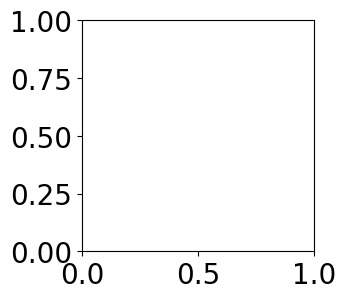

In [17]:
pparams = {
'FRB20231005A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.35),
'FRB20231204A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.5),
'FRB20231128A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.05,'pmax':98, 'stretch':'log', 'exponent':2},0.5),
'FRB20231223C' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':3,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.35),
'FRB20231025B' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':2,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.25),
'FRB20231025C' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':1,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.1),
'FRB20230926A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2}, 0.75),
'FRB20231017A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':20,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2}, 0.5),
'FRB20231123A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2}, 0.25),
'FRB20231202A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.55,'pmax':97, 'stretch':'log', 'exponent':2}, 0.5),
'FRB20231201A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':3,'pmax':99.75, 'stretch':'log', 'exponent':2}, 0.5),
'FRB20231011A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':95, 'stretch':'arcsinh', 'exponent':2}, 0.5),
'FRB20230703A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2}, 0.5),
'FRB20230730A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':7,'pmax':99.5, 'stretch':'arcsinh', 'exponent':2}, 0.25),    
'FRB20230203A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.5),
'FRB20230222B' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.5),
'FRB20230222A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.5),
'FRB20231206A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.5),
'FRB20231007B' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':10,'pmax':97, 'stretch':'arcsinh', 'exponent':2},0.5),
'FRB20230311A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75,'stretch':'arcsinh','exponent':2},0.35),
'FRB20231230A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75,'stretch':'arcsinh','exponent':2},0.75), # neeed this
'FRB20231229A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75,'stretch':'arcsinh','exponent':2},1.0)
}
import json

for evid,row in final[final['name'] == 'FRB20231230A'].iterrows():
    if 1:#row['name'] == 'FRB20231230A':
        sup_fig,ax = plt.subplots(figsize=(3,3),nrows = 1, ncols = 1)
        path_obj = FakePATH(ra = row['primary_ra'],dec = row['primary_dec'],theta = row['theta'],
                    a_err = row['a_err'], b_err = row['b_err'],
                    candidates = pd.read_excel(f"/arc/home/calvin/kko_host_paper/data_products/b_err_1.3_PATH/{row['name']}/{row['name']}_PATH_candidates.xlsx")
               )
        fig = plot_color_image(sup_fig,path_obj,TNS_name = row['name'],size_arcmin = pparams[row['name']][1], survey_str = row['primary_id'].split(' ')[0],
             #path_to_rgb = f'/arc/home/calvin/kko_host_paper/data_products/hg_images/{row["name"]}_rgb_2d.fits',
             outfile = f'/arc/home/calvin/kko_host_paper/data_products/hg_images/{row["name"]}.png',
                    cmap='spring', smooth=None, kernel='gauss',flip = True, delete = True,
                    aspect='equal', interpolation='nearest',**pparams[row['name']][0])
        fig.add_label(x = 0.05,y=0.95,relative=True,
                  text=row['name'] + '\n' + f"z={row['primary_z_spec']:.2f}",color = 'black',size=20,
                  horizontalalignment='left',verticalalignment='top',
                  #bbox=dict(facecolor='green', edgecolor='none', boxstyle='round')
                 )

        fig.remove_grid()
        fig.axis_labels.hide()
        fig.tick_labels.hide()
        fig.ticks.hide()
        ax.set_yticks([])
        ax.set_xticks([])
        plt.show()
        sup_fig.savefig(os.path.join(PATH_TO_KKO_HOST_PAPER,f'figures/{row["name"]}.pdf'),dpi = 100)


# PATH zoomout pre-download
Run plot_color_image to download...

In [18]:
pparams = {
'FRB20231005A' : ({'vmin':30, 'vmax':128,'vmid':64, 'pmin':0.25,'pmax':99.75, 'stretch':'linear', 'exponent':2},0.5),
'FRB20231204A' : ({'vmin':0, 'vmax':128,'vmid':64, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.5),
'FRB20231128A' : ({'vmin':0, 'vmax':128,'vmid':64, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.5),
'FRB20231223C' : ({'vmin':0, 'vmax':128,'vmid':64, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.25),
'FRB20231025B' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':2,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.25),
'FRB20231025C' : ({'vmin':0, 'vmax':128,'vmid':64, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.20),
'FRB20230926A' : ({'vmin':0, 'vmax':128,'vmid':64, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2}, 0.5),
'FRB20231017A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':20,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2}, 0.5),
'FRB20231123A' : ({'vmin':0, 'vmax':128,'vmid':64, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2}, 0.5),
'FRB20231202A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.55,'pmax':97, 'stretch':'log', 'exponent':2}, 0.5),
'FRB20231201A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':3,'pmax':99.75, 'stretch':'log', 'exponent':2}, 0.5),
'FRB20231011A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':95, 'stretch':'arcsinh', 'exponent':2}, 0.5),
'FRB20230703A' : ({'vmin':0, 'vmax':128,'vmid':64, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2}, 0.5),
'FRB20230730A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':7,'pmax':99.5, 'stretch':'arcsinh', 'exponent':2}, 0.25),    
'FRB20230203A' : ({'vmin':0, 'vmax':128,'vmid':64, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.5),
'FRB20230222B' : ({'vmin':0, 'vmax':128,'vmid':64, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.5),
'FRB20230222A' : ({'vmin':0, 'vmax':128,'vmid':64, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.5),
'FRB20231206A' : ({'vmin':0, 'vmax':128,'vmid':64, 'pmin':0.25,'pmax':99.75, 'stretch':'arcsinh', 'exponent':2},0.5),
'FRB20231007B' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':10,'pmax':97, 'stretch':'arcsinh', 'exponent':2},0.35),
'FRB20230311A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75,'stretch':'arcsinh','exponent':2},0.5),
'FRB20231230A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75,'stretch':'arcsinh','exponent':2},0.75), # neeed this
'FRB20231229A' : ({'vmin':None, 'vmax':None,'vmid':None, 'pmin':0.25,'pmax':99.75,'stretch':'arcsinh','exponent':2},1.0) # and this
}
import json

for evid,row in final.iterrows():
    if row['name'] == 'FRB20231230A':
        sup_fig,ax = plt.subplots(figsize=(3,3),nrows = 1, ncols = 1)
        # SO BAD but re-run plot_color_image without flipping so that we can download the files for the next step
        path_obj = FakePATH(ra = row['primary_ra'],dec = row['primary_dec'],theta = row['theta'],
                        a_err = row['a_err'], b_err = row['b_err'],
                        candidates = pd.read_excel(f"/arc/home/calvin/kko_host_paper/data_products/b_err_1.3_PATH/{row['name']}/{row['name']}_PATH_candidates.xlsx")
                   )
        survey_str = row['primary_id'].split(' ')[0]
        if survey_str[0] == 'P':
            filt = 'grz'
        elif survey_str[0] == 'D':
            filt = 'grz'
        print(survey_str)
        filt = 'grizy'
        fig = plot_color_image(sup_fig,path_obj,
                           TNS_name = row['name'],
                           zoom_width = 6,
                           zoom_height = 12,
                           size_arcmin = 10,
                           survey_str = survey_str,
                           filt = filt,
                 outfile = f'/arc/home/calvin/kko_host_paper/data_products/path_images/{row["name"]}_path.png',delete = False, flip = False,
                    cmap='spring', smooth=None, kernel='gauss',
                    aspect='equal', interpolation='nearest',**pparams[row['name']][0])


DECaL
Make plot!
/arc/home/calvin/kko_host_paper/data_products/path_images/FRB20231230A_rgb_2d.fits
INFO: Auto-setting vmin to  8.524e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.083e+02 [aplpy.core]


/opt/pysetup/.venv/lib/python3.8/site-packages/aplpy/overlays.py:256: UserWarning: Text labels do not have attribute height. Skipping.
  warnings.warn("Text labels do not have attribute {0}. Skipping.".format(kwarg))


/opt/pysetup/.venv/lib/python3.8/site-packages/aplpy/core.py:256: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self._figure = plt.figure(**kwargs)


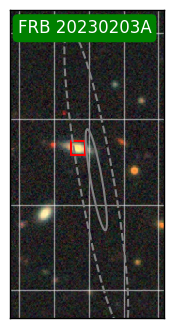

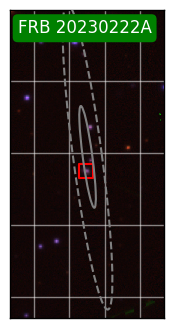

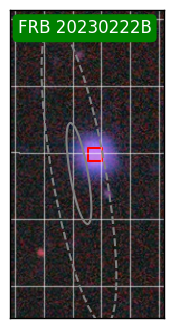

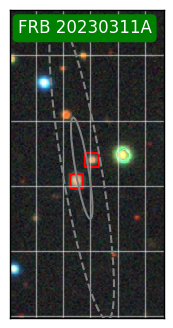

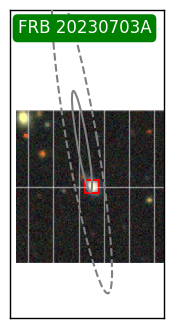

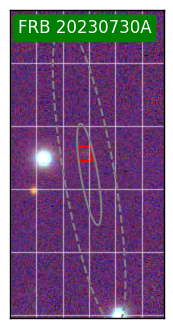

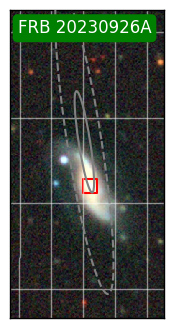

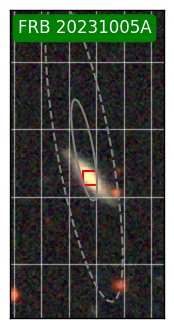

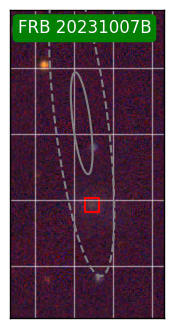

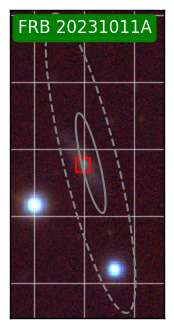

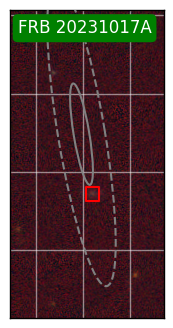

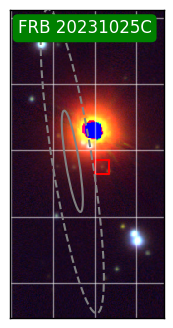

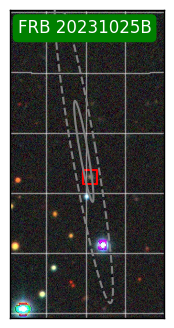

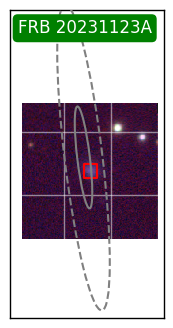

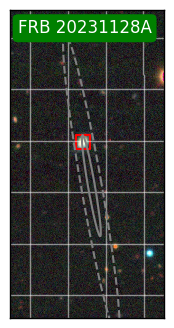

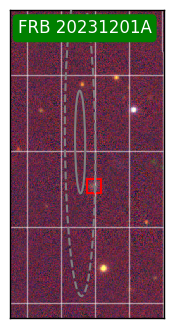

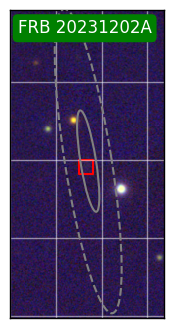

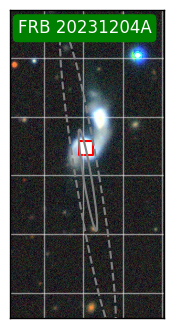

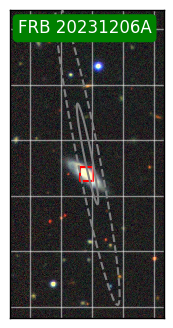

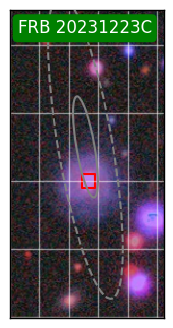

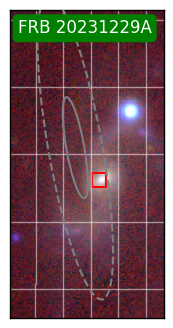

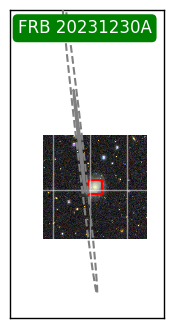

In [22]:
# Actually plot 
pparams_zoomout = {
'FRB20231005A' : ['top'],
'FRB20231204A' : ['top'],
'FRB20231128A' : ['top'],
'FRB20231223C' : ['top'],
'FRB20231025B' : ['top'],
'FRB20231025C' : ['top'],
'FRB20230926A' : ['top'],
'FRB20231017A' : ['top'],
'FRB20231123A' : ['top'],
'FRB20231202A' : ['top'],
'FRB20231201A' : ['top'],
'FRB20231011A' : ['top'],
'FRB20230703A' : ['top'],
'FRB20230730A' : ['top'],
'FRB20230203A' : ['top'],
'FRB20230222B' : ['top'],
'FRB20230222A' : ['top'],
'FRB20231206A' : ['top'],
'FRB20231007B' : ['top'],
'FRB20230311A' : ['top'],
'FRB20231229A' : ['top'],
'FRB20231230A' : ['top'],
}
for evid,row in final.iterrows():
    if row['name'] in pparams.keys():
        path_obj = FakePATH(ra = row['ra_frb'],dec = row['dec_frb'],theta = row['theta'],
                    a_err = row['a_err'], b_err = row['b_err'],
                    candidates = pd.read_excel(f"/arc/home/calvin/kko_host_paper/data_products/b_err_1.3_PATH/{row['name']}/{row['name']}_PATH_candidates.xlsx")
               )
        tns = row['name']
        fig = aplpy.FITSFigure(data = f'/arc/home/calvin/kko_host_paper/data_products/path_images/{tns}_rgb_2d.fits',figsize = (8,4))
        fig.show_rgb(filename = f'/arc/home/calvin/kko_host_paper/data_products/path_images/{tns}_rgb.png')
        #fig.show_colorscale()
        #fig.set_title("{0} {1}-Image for FRB: {2}".format(
        #    survey_str, filt, TNS_name), fontsize=20)
        fig.add_grid()
        fig.set_nan_color('black')
        fig.grid.set_color('white')
        fig.grid.set_alpha(0.5)
        fig.grid.set_linestyle('solid')
        fig.grid.set_linewidth(1)
        #fig.show_markers(ra, dec, facecolor='black', marker='+', s=300)
        #fig.add_scalebar(length = 1/60, corner = 'bottom left',height = 0.5,label = "1'",color = 'white')
        # Note: width and height parameters should be 2 times semi-major/minor axes
        # Localization
        # Note: width and height parameters should be 2 times semi-major/minor axes
        ra = path_obj.localiz['center_coord'].ra
        dec = path_obj.localiz['center_coord'].dec
        ra_val = ra.value
        dec_val = dec.value
        fig.show_ellipses(ra, dec, 2.*path_obj.localiz['eellipse']['a'] / 3600., 
                              2.*path_obj.localiz['eellipse']['b'] / 3600., 
                              angle=90+path_obj.localiz['eellipse']['theta'],
                              edgecolor='gray', lw=1.5,zorder = 99)
        fig.show_ellipses(ra, dec, 3*2.*path_obj.localiz['eellipse']['a'] / 3600., 
                              3*2.*path_obj.localiz['eellipse']['b'] / 3600., 
                              angle=90+path_obj.localiz['eellipse']['theta'],
                              edgecolor='gray', lw=1.5, ls='dashed',zorder = 99)
        if pparams_zoomout[row['name']][0] == 'top':
            fig.add_label(x = 0.05,y=0.97,relative=True,text= row['name'][0:3] + ' ' + row['name'][3:],color = 'white',size=12,
                      horizontalalignment='left',verticalalignment='top',
                      bbox=dict(facecolor='green', edgecolor='none', boxstyle='round'),zorder = 100)
        else:
            fig.add_label(x = 0.05,y=0.03,relative=True,text= row['name'][0:3] + ' ' + row['name'][3:],color = 'white',size=12,
                      horizontalalignment='left',verticalalignment='bottom',
                      bbox=dict(facecolor='green', edgecolor='none', boxstyle='round'))
        for ii, cand in path_obj.candidates.iterrows():
            if cand['P_Ox'] == np.max(path_obj.candidates['P_Ox']) or (cand['P_Ox'] > 0.05):
                ra_cand = cand['ra']
                dec_cand = cand['dec']
                fig.show_markers(ra_cand, dec_cand, edgecolor='red', facecolor='none', marker='s', s=100, lw=1.5)
        height=max(6.*path_obj.localiz['eellipse']['a'] / 3600, 2 * np.abs(dec_val - dec_cand))
        #width=max(1.5 / 60, 2 * np.abs(ra_val - ra_cand))
        width = height / 2
        fig.recenter((ra_val + ra_cand) * 0.5,(dec_val + dec_cand) * 0.5, 
            width=width,height=height 
                    )
        fig.axis_labels.hide()
        fig.tick_labels.hide()
        fig.ticks.hide()
        plt.gca().set_yticks([])
        plt.gca().set_xticks([])
        outfile = f'/arc/home/calvin/kko_host_paper/figures/{row["name"]}_path.pdf'
        plt.savefig(outfile)


# Color zoom-in

DECaL
Make plot!
/arc/home/calvin/kko_host_paper/data_products/path_images/FRB20230203A_rgb_2d.fits
INFO: Auto-setting vmin to -5.657e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.169e+02 [aplpy.core]


/opt/pysetup/.venv/lib/python3.8/site-packages/aplpy/overlays.py:256: UserWarning: Text labels do not have attribute height. Skipping.
  warnings.warn("Text labels do not have attribute {0}. Skipping.".format(kwarg))


linewidth vertical: 3.112934849157961e-05
linewidth horizont: 2.5280534722222225e-05
DECaL
Make plot!
/arc/home/calvin/kko_host_paper/data_products/path_images/FRB20230311A_rgb_2d.fits
INFO: Auto-setting vmin to -8.464e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.772e+02 [aplpy.core]


/opt/pysetup/.venv/lib/python3.8/site-packages/aplpy/overlays.py:256: UserWarning: Text labels do not have attribute height. Skipping.
  warnings.warn("Text labels do not have attribute {0}. Skipping.".format(kwarg))


linewidth vertical: 1.124302188463831e-05
linewidth horizont: 6.295979166666667e-06
DECaL
Make plot!
/arc/home/calvin/kko_host_paper/data_products/path_images/FRB20230703A_rgb_2d.fits
INFO: Auto-setting vmin to -7.581e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.427e+02 [aplpy.core]


...

linewidth vertical: 1.521022207656118e-05
linewidth horizont: 1.1124104166666665e-05
DECaL
Make plot!
/arc/home/calvin/kko_host_paper/data_products/path_images/FRB20231204A_rgb_2d.fits
INFO: Auto-setting vmin to -5.233e+00 [aplpy.core]
INFO: Auto-setting vmax to  1.936e+02 [aplpy.core]


/opt/pysetup/.venv/lib/python3.8/site-packages/aplpy/overlays.py:256: UserWarning: Text labels do not have attribute height. Skipping.
  warnings.warn("Text labels do not have attribute {0}. Skipping.".format(kwarg))


linewidth vertical: 3.9829184638502486e-05
linewidth horizont: 2.658858333333333e-05
DECaL
Make plot!
/arc/home/calvin/kko_host_paper/data_products/path_images/FRB20231206A_rgb_2d.fits
INFO: Auto-setting vmin to -8.678e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.403e+02 [aplpy.core]


/opt/pysetup/.venv/lib/python3.8/site-packages/aplpy/overlays.py:256: UserWarning: Text labels do not have attribute height. Skipping.
  warnings.warn("Text labels do not have attribute {0}. Skipping.".format(kwarg))


linewidth vertical: 7.07346392829779e-05
linewidth horizont: 3.929472916666667e-05


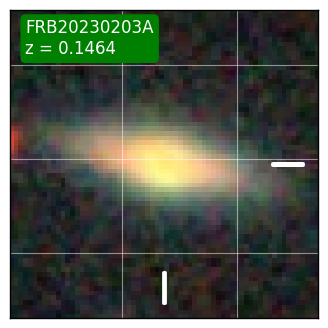

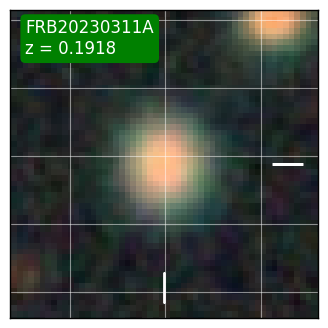

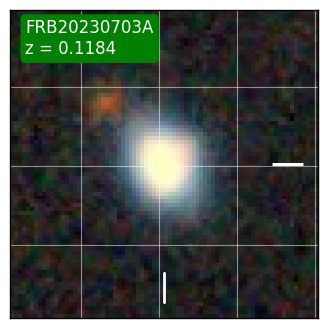

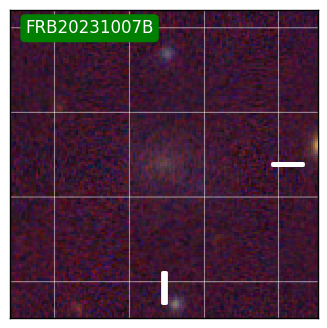

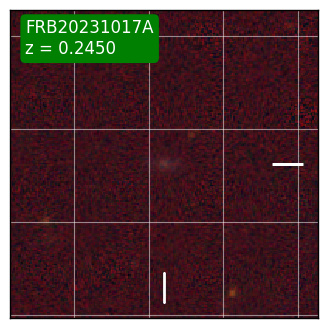

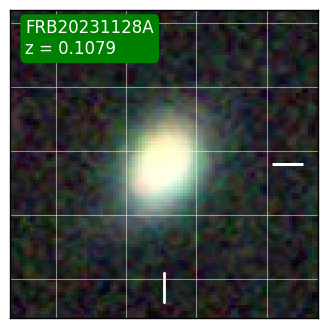

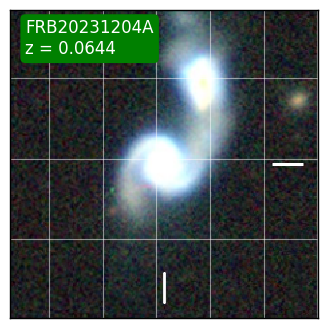

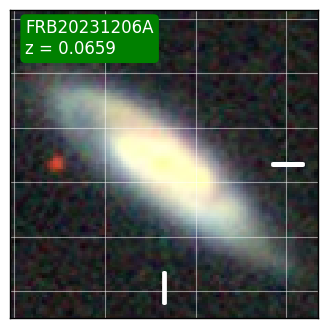

In [80]:
# Actually plot 

pparams = {
'FRB20231005A' : (5,),
'FRB20231204A' : (3,),
'FRB20231128A' : (3,),
'FRB20231223C' : (5,),
'FRB20231025B' : (5,),
'FRB20231025C' : (5,),
'FRB20230926A' : (5,),
'FRB20231017A' : (3,),
'FRB20231123A' : (3.5,),
'FRB20231202A' : (5,),
'FRB20231201A' : (5,),
'FRB20231011A' : (5,),
'FRB20230703A' : (3,),
'FRB20230730A' : (8,),
'FRB20230203A' : (0.9,),
'FRB20230222B' : (5,),
'FRB20230222A' : (5,),
'FRB20231206A' : (1,),
'FRB20231007B' : (1.2,),
'FRB20230311A' : (3,),
'FRB20231230A' : (1000,),
'FRB20231229A' : (1.5,),
}
import json

def draw_crosshairs(fig,ra,dec,inner,outer,linewidth):
    length = np.abs(outer - inner)
    #fig.show_rectangles(ra, dec, 1/3600,1/3600,edgecolor = 'white', facecolor = 'white')
    fig.show_rectangles(ra, 
                        dec - (inner + outer) * 0.5, 
                        width = linewidth / np.cos(dec * np.pi / 180), 
                        height = length,
                        linewidth = 2,
                        facecolor = 'white',
                        edgecolor = 'white',
                        joinstyle = None) # vertical at 6 o clock
    print('linewidth vertical:', linewidth / np.cos(dec * np.pi / 180))
    print('linewidth horizont:', linewidth )
    fig.show_rectangles(ra - (inner + outer) * 0.5 / np.cos(dec * np.pi / 180), 
                        dec, 
                        width = length, 
                        height = linewidth, 
                        linewidth = 2,
                        facecolor = 'white',
                        edgecolor = 'white',
                        joinstyle=None) # horizontal at 3 o clock
    #fig.show_rectangles(ra + outer, dec - linewidth / 2 , length , linewidth,edgecolor = 'white',facecolor = 'white') # horiz

for evid,row in final.iterrows():
    if row['name'][-5:] in '0703A, 1007B, 0311A, 0203A, 1017A, 1128A, 1204A, 1206A':
        sup_fig,ax = plt.subplots(figsize=(3,3),nrows = 1, ncols = 1)
        # SO BAD but re-run plot_color_image without flipping so that we can download the files for the next step
        path_obj = FakePATH(ra = row['primary_ra'],dec = row['primary_dec'],theta = row['theta'],
                        a_err = row['a_err'], b_err = row['b_err'],
                        candidates = pd.read_excel(f"/arc/home/calvin/kko_host_paper/data_products/b_err_1.3_PATH/{row['name']}/{row['name']}_PATH_candidates.xlsx")
                   )
        survey_str = row['primary_id'].split(' ')[0]
        if survey_str[0] == 'P':
            filt = 'grz'
        elif survey_str[0] == 'D':
            filt = 'grz'
        print(survey_str)
        filt = 'grizy'
        factor = pparams[row['name']][0] # how much to zoom in
        size_arcsec = np.squeeze(path_obj.candidates[path_obj.candidates['P_Ox'] == np.max(path_obj.candidates['P_Ox'])]['ang_size'].values)
        fig = plot_color_image(sup_fig,path_obj,
                           TNS_name = row['name'][0:3] + ' ' + row['name'][3:],
                           zoom_width  = np.clip(15 * size_arcsec / 60, a_min = 2, a_max = 7),
                           zoom_height = np.clip(15 * size_arcsec / 60, a_min = 2, a_max = 7),
                           size_arcmin = np.clip(15 * size_arcsec / 60, a_min = 2, a_max = 7),
                           survey_str = survey_str,
                           filt = filt,
                 outfile = f'/arc/home/calvin/kko_host_paper/data_products/path_images/{row["name"]}_path.png',delete = False, flip = False,
                    cmap='spring', smooth=None, kernel='gauss',
                    aspect='equal', interpolation='nearest')
        tns = row['name']
        fig = aplpy.FITSFigure(data = f'/arc/home/calvin/kko_host_paper/data_products/path_images/{tns}_rgb_2d.fits',figsize = (8,4))
        fig.show_rgb(filename = f'/arc/home/calvin/kko_host_paper/data_products/path_images/{tns}_rgb.png')
        #fig.show_colorscale()
        #fig.set_title("{0} {1}-Image for FRB: {2}".format(
        #    survey_str, filt, TNS_name), fontsize=20)
        fig.add_grid()
        fig.set_nan_color('black')
        #fig.grid.set_color('white')
        #fig.grid.set_alpha(0.5)
        #fig.grid.set_linestyle('solid')
        #fig.grid.set_linewidth(1)
        #fig.show_markers(ra, dec, facecolor='black', marker='+', s=300)
        #fig.add_scalebar(length = 1/60, corner = 'bottom left',height = 0.5,label = "1'",color = 'white')
        # Note: width and height parameters should be 2 times semi-major/minor axes
        # Localization
        # Note: width and height parameters should be 2 times semi-major/minor axes
        ra = path_obj.localiz['center_coord'].ra
        dec = path_obj.localiz['center_coord'].dec
        ra_val = ra.value
        dec_val = dec.value
        text = row['name']
        if row['primary_z_spec'] > 0:
            text = row['name'] + '\n' + f'z = {row["primary_z_spec"]:.4f}'
        fig.add_label(x = 0.05,y=0.97,relative=True,text=text,color = 'white',size=12,
                      horizontalalignment='left',verticalalignment='top',
                      bbox=dict(facecolor='green', edgecolor='none', boxstyle='round'),zorder = 100)
        for ii, cand in path_obj.candidates.iterrows():
            if cand['P_Ox'] == np.max(path_obj.candidates['P_Ox']):
                ra_cand = cand['ra']
                dec_cand = cand['dec']
                ang_cand = 5 * cand['ang_size'] / 60 / 60 # convert to degrees
        assert ra_cand == row['primary_ra'],'wrong ra?'
        assert dec_cand == row['primary_dec'],'wrong dec?'
        height = ang_cand * factor 
        width = ang_cand * factor
        fig.recenter(ra_cand, dec_cand,
            width=width,height=height 
                    )
        draw_crosshairs(fig,
                        ra_cand,
                        dec_cand,
                        inner = factor * ang_cand * 0.35, 
                        outer = factor * ang_cand * 0.45, linewidth = ang_cand * 0.005)
        fig.axis_labels.hide()
        fig.tick_labels.hide()
        fig.ticks.hide()
        plt.gca().set_yticks([])
        plt.gca().set_xticks([])
        outfile = f'/arc/home/calvin/kko_host_paper/figures/{row["name"]}_color.pdf'
        plt.savefig(outfile)


In [ ]:
        draw_crosshairs(fig,ra_cand,dec_cand,inner = ang_cand * 3, outer = ang_cand * 3.5, linewidth = ang_cand * 0.01)


In [32]:
fig.show_grayscale()

INFO: Auto-setting vmin to  6.140e+00 [aplpy.core]
INFO: Auto-setting vmax to  1.679e+02 [aplpy.core]


In [ ]:
path_obj.candidates

,ra,dec,ang_size,mag,ID,sep,P_O,p_xO,P_Ox,P_Ux,z_phot_median,z_phot_l68,z_phot_u68,z_phot_l95,z_phot_u95,z_spec,survey
0,72.789122,2.368060,12.471317,14.647030,10995476588397444,98.163698,0.130631,0.000014,0.917597,0.017705,0.023856,0.020162,0.029262,0.012689,0.069875,-99,DECaL
1,72.801909,2.433344,0.710954,20.833185,10995478098347116,142.569988,0.000101,0.000261,0.013203,0.017705,0.275685,0.229470,0.380521,0.162909,0.448673,-99,DECaL
2,72.800570,2.413930,0.516175,21.580793,10995478098347099,72.622200,0.000049,0.000303,0.007514,0.017705,0.517676,0.470043,0.558763,0.365371,0.602299,-99,DECaL
3,72.793197,2.350084,1.229232,20.690342,10995476588397555,158.801458,0.000116,0.000124,0.007172,0.017705,0.205042,0.153431,0.265280,0.121492,0.357773,-99,DECaL
4,72.798514,2.399079,1.161609,22.570148,10995478098347052,18.659039,0.000020,0.000601,0.006093,0.017705,0.580044,0.350752,0.972404,0.175871,1.480399,-99,DECaL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12181,72.818323,2.274991,1.364586,23.199566,10995476588398091,434.772739,0.000012,0.000000,0.000000,0.017705,1.022165,0.855563,1.177169,0.579565,1.334129,-99,DECaL
12182,72.821688,2.275911,0.329127,23.691542,10995476588398177,433.763150,0.000008,0.000000,0.000000,0.017705,0.787567,0.667420,0.917694,0.543707,1.074610,-99,DECaL
12183,72.819025,2.282847,0.268488,22.750780,10995476588398109,407.407976,0.000017,0.000000,0.000000,0.017705,0.500688,0.399731,0.610454,0.294732,0.751659,-99,DECaL
12184,72.813955,2.278944,0.297388,23.508469,10995476588397980,418.262432,0.000009,0.000000,0.000000,0.017705,0.904268,0.773383,1.039620,0.657144,1.229894,-99,DECaL


In [76]:

for evid,row in final[final['primary_P_Ox'] > 0.9].sort_index().iterrows():
    print('\includegraphics[width=0.25\pagewidth]{' + row['name'] + '.pdf}')

\includegraphics[width=0.25\pagewidth]{FRB20230203A.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20230222A.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20230222B.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20230703A.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20230730A.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20230926A.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20231005A.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20231007B.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20231011A.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20231017A.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20231025C.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20231025B.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20231123A.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20231128A.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20231201A.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20231202A.pdf}
\includegraphics[width=0.25\pagewidth]{FRB20231204A.pdf}
\includegraphics[width=0.25\pag

# Old plotting Code Below: Ignore

In [268]:

import os

from io import BytesIO
from io import StringIO
import requests
from PIL import Image

import numpy as np
import pandas

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'axes.labelsize':20,
         'axes.titlesize':20,
         'xtick.labelsize':20,
         'ytick.labelsize':20}
pylab.rcParams.update(params)
from matplotlib import rc
#rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=False)

import aplpy

from reproject.mosaicking import find_optimal_celestial_wcs
from reproject import reproject_interp
from reproject.mosaicking import reproject_and_coadd

from astropy.coordinates import SkyCoord, angular_separation
from astropy import units 
from astropy.table import Table, vstack, unique
from astropy.io import fits
from astropy import utils as astropy_utils
import astropy.units as u

from frb.surveys import survey_utils

from IPython import embed

def path_plot_kko_paper(
    sup_fig,
    frb_name, # Name of the FRB
    cands, # CSV from chime-ffff-pz
    im_fits, # List containing three astropy.io.fits objects for R, G, B colors
    ra : float,
    a_err : float,
    dec : float,
    b_err : float,
    theta : float,
    size_arcmins : float = 0.5, # Size of image to query in arcmins
    P_Ox_thresh : float = 0.5, # A posterior threshold for declaring candidates "interesting" enough for including on the diagnostic plot
    outfile : str = None,
    stars = None,
    a = 1, # multiplicative constant outside of arcsinh
    b = 800 # multiplicative constant inside arcsinh argument
):
    """
    Create diagnostic plot for a PATH analysis
    
    Parameter
    ---------
    path_obj : astropy.table.Table 
        A table containing PATH results. Will have columns for:
        ra, dec, angular size of the host in arcseconds, r-band magnitude, P(O), P(O|x)
    ra : float
        Right ascension (degrees)
    a_err : float
        The semi-major axis in arcseconds
    dec : float
        Declination (degrees)
    b_err : float
        The semi-major axis in arcseconds
    theta : float
        Angle of the ellipse in degrees. The angle is defined as the angle of the
        semi-major axis, as degrees East from North
    dm : float
        The FRB dispersion measure in pc/cc
    gal_dm : float
        The Milky Way DM contribution for the given FRB
    size_arcmins : float
        Size of the image to query in arcminutes
    filt : float
        The optical filter to query for the image (should be one of "g", "r", "i", "z", "y")
    P_Ox_thresh : float
        A PATH posterior threshold for declaring candidates "interesting" enough for 
        including on the diagnostic plot.
    outfile : str
        File path/filename where the PATH results will be output. Should be a .png file
    survey_str : str
        A string indicating which survey to run the PATH analysis on, should be
        'Pan-STARRS' or 'DECaL' (Dark Energy Legacy Survey). Pan-STARRS is shallower,
        to a depth of rmag ~ 23. DECaL is deeper, with a depth of rmag ~ 24. So DECaL
        is preferred, but it is not always available (only covers ~1/2 of the CHIME FOV)
        
    Return
    ------
    Path : astropy.table.Table 
        A table containing PATH results. Will have columns for:
        ra, dec, angular size of the host in arcseconds, r-band magnitude, P(O), P(O|x)
    Will output the image to a png file in outfile
    """
    size_pixels = int(size_arcmins * 60. / 0.25)
    
    interesting_cands = cands[cands['P_Ox'] > P_Ox_thresh]
        
    print('Calculate an optimal WCS to share between all the fits')
    coord = SkyCoord(ra, dec, unit=(u.deg, u.deg), frame='icrs')
    res = 0.25*u.arcsec
    wcs_out, shape_out = find_optimal_celestial_wcs(
                                                    im_fits,
                                                    resolution = res,
                                                    reference = coord,
                                                    )
    header_out = wcs_out.to_header()

    print('Generate empty datacube, reprojecting each color to the new WCS')
    image_cube = np.zeros((len(im_fits),) + shape_out, dtype=np.float32)
    for ii, im in enumerate(im_fits):
        array, footprint = reproject_interp(im, wcs_out, shape_out=shape_out)
        image_cube[ii, :, :] = array[:,::-1]
        
    output_fn = '{}_rgb_2d.fits'.format(frb_name)
    print('Write out collapsed version of cube for aplpy plotting purposes')
    fits.writeto(
        output_fn,
        np.nanmean(image_cube,axis = 0),
        header_out, 
        overwrite=True,
    )
    
    print('Save the reprojected fits into a PNG, also for aplpy plotting purposes')

    img = Image.fromarray(image_cube[0].astype(np.uint8))
    img.save(output_fn.replace('_2d.fits', '.png'))

    print('Make plot!')

    fig = aplpy.FITSFigure(output_fn, figure=sup_fig, subplot=subplot_idx)

    # scale rgb image cube; reorder axes; apply arcsinh
    import scipy.stats as sps
    image_cube[0] /= sps.median_abs_deviation(image_cube[0],nan_policy='omit')
    image_cube[1] /= sps.median_abs_deviation(image_cube[1],nan_policy='omit')
    image_cube[2] /= sps.median_abs_deviation(image_cube[2],nan_policy='omit')
    image_cube = np.moveaxis(image_cube,0,-1)

    fig.ax.imshow(a* np.fliplr(np.arcsinh(np.sum(image_cube,axis=-1) * b)))
    fig.add_label(x = 0.05,y=0.95,relative=True,text=frb_name,color = 'white',size=20,horizontalalignment='left',verticalalignment='top')
    #show_rgb(fig,output_fn.replace('_2d.fits', '.png'),**imshow_kwargs)
    #fig.set_nan_color('black')
    fig.tick_labels.set_font(size=20)
    fig.axis_labels.set_font(size=20)
    # fig.set_title("{0} {1}-Filter Image for Event ID: {2}\nExcess DM: {3:.2f} pc/cc".format(survey_str, filt, event_id, dm-gal_dm), fontsize=20)
    fig.add_grid()
    fig.grid.set_color('white')
    fig.grid.set_alpha(0.5)
    fig.grid.set_linestyle('solid')
    fig.grid.set_linewidth(1)
    fig.show_markers(ra, dec, facecolor='black', marker='+', s=300, zorder=20)
    # Note: width and height parameters should be 2 times semi-major/minor axes
    rot = theta - 90
    fig.show_ellipses(ra, dec, 2.*a_err, 2.*b_err, angle=rot, edgecolor='white', lw=2)
    fig.show_ellipses(ra, dec, 2.*a_err*3, 2.*b_err*3, angle=rot, edgecolor='white', linestyle='dashed', lw=2)
    
    #fig.add_label(1.05, .9, "Path P(O|x)", color='black', size=20, relative=True, horizontalalignment='left', weight='bold')
    jj = 1
    offsets = []
    for ii, cand in interesting_cands.iterrows():
        ra_cand = cand['ra']
        dec_cand = cand['dec']
        if jj == 1:
            fig.show_markers(ra_cand, dec_cand, edgecolor='red', facecolor='none', marker='s', s=100, lw=1.5, label='Potential Hosts')
        else:
            fig.show_markers(ra_cand, dec_cand, edgecolor='red', facecolor='none', marker='s', s=100, lw=1.5)
        label_x_loc = ra_cand
        label_y_loc = dec_cand + 5./3600.
        fig.add_label(label_x_loc, label_y_loc, str(jj), color='red', size=15)
        #fig.add_label(1.05, .9-0.05*jj, "{0}\t\t{1:.3f}".format(jj,cand['P_Ox']), color='black', size=20, relative=True, horizontalalignment='left')
        jj = jj + 1
        coord_cand = SkyCoord(ra_cand, dec_cand, unit=(u.deg, u.deg), frame='icrs')
        offset = angular_separation(coord.ra.rad, coord.dec.rad, coord_cand.ra.rad, coord_cand.dec.rad) * 180. / np.pi # deg
        offsets.append(offset)
    
    # Adjustable final zoom into the localization region, but encompassing
    # any interesting sources
    print(np.array(offsets)*60*2, size_arcmins)
    zoom_width = np.nanmax([np.nanmax(offsets, initial=0)*60*2, size_arcmins])
    fig.recenter(ra, dec, width=zoom_width/60., height=zoom_width/60.)
    print(ra,dec)
    
    # Print any galaxies within zoomed region
    other_sources = cands[cands['P_Ox'] < P_Ox_thresh]
    jj_init = jj
    print("Plotting Galaxies: {}".format(len(other_sources)))
    galaxies_to_plot = []
    for ii, cand in other_sources.iterrows():
        ra_cand = cand['ra']
        dec_cand = cand['dec']
        if (ra_cand > ra + zoom_width/np.cos(dec*np.pi/180.)/60.) or (ra_cand < ra - zoom_width/np.cos(dec*np.pi/180.)/60.) or (dec_cand > dec + zoom_width/60.) or (dec_cand < dec - zoom_width/60.): 
            continue
        else:
            galaxies_to_plot.append([ra_cand, dec_cand])
    galaxies_to_plot = np.array(galaxies_to_plot)
    #fig.show_markers(galaxies_to_plot[:,0], galaxies_to_plot[:,1], facecolor='none',  edgecolor='xkcd:orange', marker='o', s=50, lw=1.5, label='Other Galaxies') # 
        
    jj = 1
    if stars is not None:
        # Print any stars within zoomed region
        stars_to_plot = []
        for ii, cand in enumerate(stars):
            ra_cand = cand['ra']
            dec_cand = cand['dec']
            if (ra_cand > ra + zoom_width/np.cos(dec*np.pi/180.)/60.) or (ra_cand < ra - zoom_width/np.cos(dec*np.pi/180.)/60.) or (dec_cand > dec + zoom_width/60.) or (dec_cand < dec - zoom_width/60.): 
                continue
            else:
                stars_to_plot.append([ra_cand, dec_cand])
        stars_to_plot = np.array(stars_to_plot)
        print("Plotting Stars: {}".format(len(stars_to_plot)))
        fig.show_markers(stars_to_plot[:,0], stars_to_plot[:,1], edgecolor='blue', facecolor='None', marker='D', s=50, lw=1.5, label='Stars') 

    if outfile is not None:
        plt.savefig(outfile, dpi=100, format="png", bbox_inches="tight")
    plt.close()
    return image_cube,fig


# Make big cutout

# Make zoom in cutout

In [121]:
import json
sup_fig_zoom,axs = plt.subplots(figsize=(20,30),nrows = 6, ncols = 4)
sup_fig_zoom.subplots_adjust(hspace = 0, wspace = 0)
ii = 0
for event_id, burst in list(csv.iterrows()):
    ax = axs.flat[ii]
    frb_tns = 'FRB' + burst['TNS']
    hg_name = 'HG' + burst['TNS']
    try:
        hdul_g = fits.open(os.path.join(PATH_TO_KKO_HOST_PAPER,f'data_products/hg_images/{event_id}_g.fits'))[0]
        hdul_r = fits.open(os.path.join(PATH_TO_KKO_HOST_PAPER,f'data_products/hg_images/{event_id}_r.fits'))[0]
        hdul_i = fits.open(os.path.join(PATH_TO_KKO_HOST_PAPER,f'data_products/hg_images/{event_id}_i.fits'))[0]
        with open(f'/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/PATH/{frb_tns}/{frb_tns}_PATH_input.json') as f:
            eellipse = json.load(f)
        
        cc,ff = path_plot_kko_paper(
            sup_fig = sup_fig_zoom,
            subplot_idx = (6,4,ii+1),
            frb_name = hg_name, # Name of the FRB
            cands = pd.read_csv(os.path.join(PATH_TO_CHIME_FFFF_PZ, f'data/PATH/{frb_tns}/{frb_tns}_PATH_candidates.csv')), # Path object with information about the localization
            im_fits = [hdul_g,hdul_r,hdul_i],
            ra =burst['hg_primary_ra'],
            a_err = 10, #too big to see
            dec =burst['hg_primary_dec'],
            b_err = 10, #too big to see
            theta =eellipse['lparam']['theta'],
            size_arcmins = 0.5, # Size of image to query in arcmins
            P_Ox_thresh = 0.5, # A posterior threshold for declaring candidates "interesting" enough for including on the diagnostic plot
            outfile = os.path.join(PATH_TO_KKO_HOST_PAPER,f'data_products/hg_images/{event_id}.png'),
            stars = None,
            a = 1,
            b = 300
        )
        ff.remove_grid()
        ff.axis_labels.hide()
        ff.tick_labels.hide()
        ff.ticks.hide()
        ax.set_yticks([])
        ax.set_xticks([])
    except FileNotFoundError:
        print('No PATH run:',frb_tns)
    ii += 1
sup_fig_zoom.savefig(os.path.join(PATH_TO_KKO_HOST_PAPER,'figures/hg_images_zoom.pdf'),dpi = 100)

Calculate an optimal WCS to share between all the fits
Generate empty datacube, reprojecting each color to the new WCS


this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]


Write out collapsed version of cube for aplpy plotting purposes
Save the reprojected fits into a PNG, also for aplpy plotting purposes


/tmp/ipykernel_1597/1024231700.py:126: RuntimeWarning: Mean of empty slice
  np.nanmean(image_cube,axis = 0),


Make plot!


...

Write out collapsed version of cube for aplpy plotting purposes
Save the reprojected fits into a PNG, also for aplpy plotting purposes
Make plot!


/tmp/ipykernel_1597/1024231700.py:126: RuntimeWarning: Mean of empty slice
  np.nanmean(image_cube,axis = 0),
/opt/pysetup/.venv/lib/python3.8/site-packages/aplpy/core.py:1176: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  s = self.ax.scatter(xw, yw, transform=self.ax.get_transform(coords_frame), **kwargs)


[5.37830024] 0.5
206.65623990206055 45.4472910304392
Plotting Galaxies: 230
Calculate an optimal WCS to share between all the fits


this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]


InvalidTransformError: ERROR 7 in wcsset() at line 2660 of file cextern/wcslib/C/wcs.c:
Ill-conditioned coordinate transformation parameter.
ERROR 4 in celset() at line 441 of file cextern/wcslib/C/cel.c:
Ill-conditioned coordinate transformation parameters
No valid solution for latp for these values of phip, phi0, and theta0.


In [122]:
frb_tns

'FRB20231005A'